# Технологии Машинного Обучения РК №1 
# Группа: ИУ5-62Б
# Студент: Кудабаева Э.
# Преподаватель: Гапанюк Ю.Е.
# Вариант №12
# Задача №2, Датасет № 4

## https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

# Задача №2.
## Для заданного набора данных проведите обработку пропусков в данных для одного категориального и одного количественного признака. 
## Какие способы обработки пропусков в данных для категориальных и количественных признаков Вы использовали? 
## Какие признаки Вы будете использовать для дальнейшего построения моделей машинного обучения и почему?

# Импорт и первичный анализ датасета

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [5]:
# Вариант 12 набор данных №4 (Heart Disease Dataset)
df = pd.read_csv('heart.csv')

print("Размер:", df.shape)
df.head()

Размер: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


# Создаём пропуски

In [7]:
# в исходном датасете пропусков нет, создаем искусственно
np.random.seed(42)
df_nan = df.copy()

# кол-во признак: thalach (макс. ЧСС)
# категориальный признак: cp (тип боли в груди, chest pain)
quant_col = 'thalach'
cat_col = 'cp'

n_missing = int(len(df_nan) * 0.1)
idx_quant = np.random.choice(df_nan.index, n_missing, replace=False)
idx_cat = np.random.choice(df_nan.index, n_missing, replace=False)

df_nan.loc[idx_quant, quant_col] = np.nan
df_nan.loc[idx_cat, cat_col] = np.nan

print(f"Пропусков в {quant_col}: {df_nan[quant_col].isna().sum()}")
print(f"Пропусков в {cat_col}: {df_nan[cat_col].isna().sum()}")

Пропусков в thalach: 102
Пропусков в cp: 102


# Задача №2. Обработка пропусков

In [10]:
df_clean = df_nan.copy()

# кол-во признак - медиана
med_val = df_clean[quant_col].median()
df_clean[quant_col] = df_clean[quant_col].fillna(med_val)

# категориальный признак - мода
mode_val = df_clean[cat_col].mode()[0]
df_clean[cat_col] = df_clean[cat_col].fillna(mode_val)

print(f"Медиана {quant_col}: {med_val}")
print(f"Мода {cat_col}: {mode_val}")
print(f"Пропусков после обработки: {df_clean.isna().sum().sum()}")

print("\nРаспределение cp после заполнения:")
print(df_clean['cp'].value_counts().sort_index())

print("\nСтатистика thalach после заполнения:")
print(df_clean['thalach'].describe())

Медиана thalach: 152.0
Мода cp: 0.0
Пропусков после обработки: 0

Распределение cp после заполнения:
cp
0.0    552
1.0    145
2.0    259
3.0     69
Name: count, dtype: int64

Статистика thalach после заполнения:
count    1025.000000
mean      149.583415
std        21.994831
min        71.000000
25%       138.000000
50%       152.000000
75%       164.000000
max       202.000000
Name: thalach, dtype: float64


# **Задача №2**

## **Способы обработки пропусков:**
- Для количественного признака (thalach) использовали заполнение медианой. Медиана устойчива к выбросам, которые могут присутствовать в данных о ЧСС.
- Для категориального признака (cp) использовали заполнение модой (самым частым значением). Это сохраняет исходное распределение категорий.

## **Признаки для дальнейшего построения моделей:**
Будем использовать все признаки датасета:
- age, sex, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, cp
- целевая переменная: target

## Все признаки содержат информацию о состоянии пациента и могут быть полезны для предсказания сердечных заболеваний.

In [14]:
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
            'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

X = df_clean[features]
y = df_clean['target']

np.random.seed(42)
shuffled_idx = np.random.permutation(len(X))
X_shuffled = X.iloc[shuffled_idx]
y_shuffled = y.iloc[shuffled_idx]

print(f"Признаки ({len(features)} шт.): {', '.join(features)}")
print(f"Целевая переменная: target")
print(f"\nРазмер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"\nПервые 10 строк X:")
print(X_shuffled.head(10))
print(f"\nПервые 10 значений y:")
print(y_shuffled.head(10).values)

Признаки (13 шт.): age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal
Целевая переменная: target

Размер X: (1025, 13)
Размер y: (1025,)

Первые 10 строк X:
     age  sex   cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
527   62    0  0.0       124   209    0        1    152.0      0      0.0   
359   53    0  2.0       128   216    0        0    152.0      0      0.0   
447   55    1  0.0       160   289    0        0    152.0      1      0.8   
31    50    0  1.0       120   244    0        1    152.0      0      1.1   
621   48    1  0.0       130   256    1        0    152.0      1      0.0   
590   74    0  1.0       120   269    0        0    152.0      1      0.2   
905   64    1  0.0       120   246    0        0    152.0      1      2.2   
737   67    1  0.0       120   229    0        0    152.0      1      2.6   
76    48    1  2.0       124   255    1        1    152.0      0      0.0   
948   70    1  0.0       145   174    0

# (ИУ5-62Б) - Гистограмма

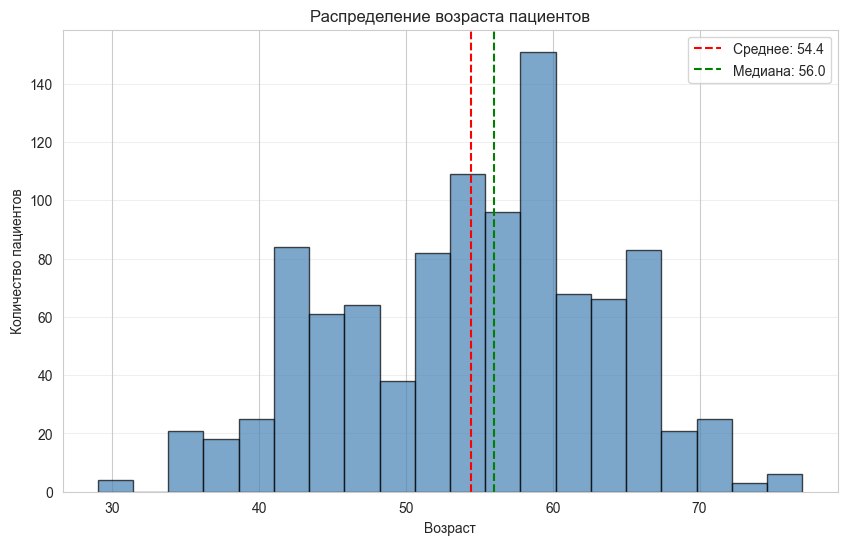

Минимум: 29, Максимум: 77


In [13]:
plt.figure(figsize=(10, 6))
plt.hist(df['age'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(df['age'].mean(), color='red', linestyle='--', label=f'Среднее: {df["age"].mean():.1f}')
plt.axvline(df['age'].median(), color='green', linestyle='--', label=f'Медиана: {df["age"].median():.1f}')
plt.xlabel('Возраст')
plt.ylabel('Количество пациентов')
plt.title('Распределение возраста пациентов')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Минимум: {df['age'].min()}, Максимум: {df['age'].max()}")